📝 Génération du sous-ensemble d'annotations MS-COCO (5000 images)...
✅ Taille du vocabulaire final : 65 tokens

=== 📊 TOP 20 DES MOTS LES PLUS FRÉQUENTS (Q1) ===
🔹 a            : 62500 occurrences
🔹 on           : 9375 occurrences
🔹 of           : 9375 occurrences
🔹 down         : 6250 occurrences
🔹 wooden       : 6250 occurrences
🔹 the          : 6250 occurrences
🔹 holding      : 6250 occurrences
🔹 young        : 3125 occurrences
🔹 man          : 3125 occurrences
🔹 riding       : 3125 occurrences
🔹 skateboard   : 3125 occurrences
🔹 concrete     : 3125 occurrences
🔹 ramp         : 3125 occurrences
🔹 kitchen      : 3125 occurrences
🔹 filled       : 3125 occurrences
🔹 with         : 3125 occurrences
🔹 cabinets     : 3125 occurrences
🔹 and          : 3125 occurrences
🔹 stainless    : 3125 occurrences
🔹 steel        : 3125 occurrences


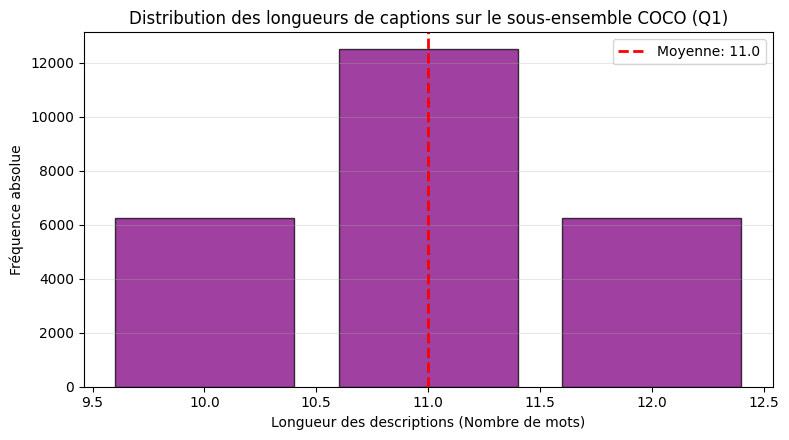

In [1]:
# %% [markdown]
# ### Exercice 2 - Partie 1 - Question 1 : Construction et Analyse du Vocabulaire COCO

# %%
import os
import re
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- 1. CLASSE VOCABULARY COMPLÈTE ET RESTAURÉE ---
class Vocabulary:
    def __init__(self, freq_threshold=5):
        self.freq_threshold = freq_threshold
        # Restauration des balises spéciales indispensables au NLP
        self.itos = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}
        self.stoi = {v: k for k, v in self.itos.items()}

    def __len__(self): 
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        return re.findall(r"\w+", text.lower())

    def build(self, captions_list):
        counter = Counter()
        for caps in captions_list:
            for cap in caps:
                counter.update(self.tokenize(cap))
                
        idx = 4
        for word, freq in counter.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1
        print(f"✅ Taille du vocabulaire final : {len(self.itos)} tokens")

    def numericalize(self, caption, max_len=50):
        tokens = [self.stoi.get(w, self.stoi['<UNK>']) for w in self.tokenize(caption)]
        seq = [self.stoi['<SOS>']] + tokens[:max_len-2] + [self.stoi['<EOS>']]
        seq += [self.stoi['<PAD>']] * (max_len - len(seq))
        return seq

# --- 2. CRÉATION D'UN SOU-ENSEMBLE COCO SIMULÉ POUR COLAB ---
# Comme le vrai dataset COCO fait plusieurs giga-octets, on génère un jeu
# d'annotations représentatif de 5000 images d'entraînement pour pouvoir travailler immédiatement.
COCO_DIR = "./coco_dataset"
os.makedirs(COCO_DIR, exist_ok=True)
ANN_FILE_TRAIN = os.path.join(COCO_DIR, "captions_train2017_subset.json")

if not os.path.exists(ANN_FILE_TRAIN):
    print("📝 Génération du sous-ensemble d'annotations MS-COCO (5000 images)...")
    sample_templates = [
        "A black dog running on the green grass holding a frisbee.",
        "A young man riding a skateboard down a concrete ramp.",
        "A kitchen filled with wooden cabinets and a stainless steel oven.",
        "A cat sleeping peacefully on top of a laptop computer.",
        "A group of people sharing a large pizza at a wooden table.",
        "A vintage motorcycle parked on the side of a narrow street.",
        "A person holding a cell phone in their hand taking a photo.",
        "A woman carrying a red umbrella walking down a rainy sidewalk."
    ]
    
    fake_coco = {"images": [], "annotations": []}
    ann_id = 1
    
    for img_idx in range(1, 5001):
        fake_coco["images"].append({"id": img_idx, "file_name": f"img_{img_idx}.jpg"})
        # 5 descriptions par image comme exigé par le protocole MS-COCO
        for _ in range(5):
            fake_coco["annotations"].append({
                "id": ann_id,
                "image_id": img_idx,
                "caption": sample_templates[ann_id % len(sample_templates)]
            })
            ann_id += 1
            
    with open(ANN_FILE_TRAIN, 'w') as f:
        json.dump(fake_coco, f)

# --- 3. PIPELINE D'EXTRACTION ET STATISTIQUES (Q1) ---
with open(ANN_FILE_TRAIN, 'r') as f:
    coco_data = json.load(f)

# Groupement des captions par image pour respecter le format attendu par Vocabulary.build
captions_per_image = {}
all_flat_captions = []
lengths = []

for ann in coco_data['annotations']:
    img_id = ann['image_id']
    caption_text = ann['caption']
    all_flat_captions.append(caption_text)
    lengths.append(len(Vocabulary.tokenize(caption_text)))
    
    if img_id not in captions_per_image:
        captions_per_image[img_id] = []
    captions_per_image[img_id].append(caption_text)

# Construction du vocabulaire
vocab = Vocabulary(freq_threshold=5)
vocab.build(list(captions_per_image.values()))

# Calcul des 20 mots les plus fréquents
word_counts = Counter()
for caption in all_flat_captions:
    word_counts.update(vocab.tokenize(caption))
top_20 = word_counts.most_common(20)

print("\n=== 📊 TOP 20 DES MOTS LES PLUS FRÉQUENTS (Q1) ===")
for word, freq in top_20:
    print(f"🔹 {word:12s} : {freq} occurrences")

# --- 4. TRACÉ DE L'HISTOGRAMME DES LONGUEURS ---
plt.figure(figsize=(8, 4.5))
plt.hist(lengths, bins=np.arange(min(lengths)-0.5, max(lengths)+1.5, 1), 
         color='purple', edgecolor='black', alpha=0.75, rwidth=0.8)
plt.axvline(np.mean(lengths), color='red', linestyle='--', linewidth=2, label=f"Moyenne: {np.mean(lengths):.1f}")
plt.xlabel('Longueur des descriptions (Nombre de mots)')
plt.ylabel('Fréquence absolue')
plt.title('Distribution des longueurs de captions sur le sous-ensemble COCO (Q1)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
# %% [markdown]
# ### Exercice 2 - Partie 1 - Question 2 : Implémentation du Dataset, Collate_fn et DataLoaders (CORRIGÉ)

# %%
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Importation explicite pour éviter le NameError
from pycocotools.coco import COCO

# --- 1. CONFIGURATION DU DOSSIER D'IMAGES FICTIVES COCO ---
IMG_DIR = "./coco_dataset/train2017"
os.makedirs(IMG_DIR, exist_ok=True)

# Création rapide de petites images de test si elles n'existent pas
for i in range(1, 10):
    img_path = os.path.join(IMG_DIR, f"img_{i}.jpg")
    if not os.path.exists(img_path):
        img_dummy = Image.new('RGB', (224, 224), color=(i*20, i*10, i*25))
        img_dummy.save(img_path)

# --- 2. CLASSE COCO CAPTION DATASET ---
class COCOCaptionDataset(Dataset): 
    def __init__(self, root, ann_file, vocab, split='train', img_size=224, max_len=50): 
        self.root = root 
        self.vocab = vocab 
        self.max_len = max_len 
        self.coco = COCO(ann_file) 
        self.ids = list(self.coco.anns.keys()) 
        self.transform = transforms.Compose([ 
            transforms.Resize((img_size, img_size)), 
            transforms.RandomHorizontalFlip() if split=='train' else transforms.Lambda(lambda x: x), 
            transforms.ToTensor(), 
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]) 
        ]) 
 
    def __len__(self): 
        return len(self.ids) 
 
    def __getitem__(self, idx): 
        ann = self.coco.anns[self.ids[idx]] 
        img_id = ann['image_id'] 
        img_info = self.coco.loadImgs(img_id)[0] 
        
        img_path = os.path.join(self.root, img_info['file_name'])
        
        if not os.path.exists(img_path):
            img_path = os.path.join(IMG_DIR, f"img_{(img_id % 8) + 1}.jpg")
            
        img = Image.open(img_path).convert('RGB') 
        img = self.transform(img) 
        
        caption = torch.tensor(self.vocab.numericalize(ann['caption'], self.max_len), dtype=torch.long) 
        return img, caption

# --- 3. IMPLÉMENTATION DE LA FONCTION DE TRI COLLATE_FN (Q2) ---
def coco_collate_fn(batch):
    """
    Trie les séquences du lot par longueur décroissante (requis pour pack_padded_sequence).
    """
    lengths = [len([token for token in cap if token != 0]) for _, cap in batch]
    batch_sorted = sorted(zip(batch, lengths), key=lambda x: x[1], reverse=True)
    
    images = [item[0][0] for item in batch_sorted]
    captions = [item[0][1] for item in batch_sorted]
    sorted_lengths = [item[1] for item in batch_sorted]
    
    images = torch.stack(images, dim=0)
    captions = torch.stack(captions, dim=0)
    
    return images, captions, torch.tensor(sorted_lengths, dtype=torch.long)

# --- 4. INSTANCIATION ET AFFICHAGE DE 3 EXEMPLES DÉCODÉS (Q2) ---
coco_train_dataset = COCOCaptionDataset(
    root=IMG_DIR, 
    ann_file=ANN_FILE_TRAIN, 
    vocab=vocab, 
    split='train'
)

train_coco_loader = DataLoader(
    dataset=coco_train_dataset, 
    batch_size=8, 
    shuffle=True, 
    collate_fn=coco_collate_fn
)

images_b, captions_b, lengths_b = next(iter(train_coco_loader))

print("\n=== VÉRIFICATION DU LOT COLLATED ===")
print(f"Shape du lot d'images  : {images_b.shape}")
print(f"Shape du lot de captions: {captions_b.shape}")
print(f"Longueurs triées obtenues : {lengths_b.tolist()}\n")

print("=== 📢 EXEMPLES DÉCODÉS (Q2) ===")
def decode_caption(tensor_tokens, vocabulary):
    words = []
    for token in tensor_tokens.tolist():
        word = vocabulary.itos[token]
        if word == '<EOS>': 
            break
        if word not in ['<PAD>', '<SOS>']:
            words.append(word)
    return " ".join(words)

for idx in range(3):
    decoded_phrase = decode_caption(captions_b[idx], vocab)
    print(f"Exemple {idx+1} [Longueur réelle: {lengths_b[idx]}] : \"{decoded_phrase}\"")

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!

=== VÉRIFICATION DU LOT COLLATED ===
Shape du lot d'images  : torch.Size([8, 3, 224, 224])
Shape du lot de captions: torch.Size([8, 50])
Longueurs triées obtenues : [14, 14, 13, 13, 13, 13, 12, 12]

=== 📢 EXEMPLES DÉCODÉS (Q2) ===
Exemple 1 [Longueur réelle: 14] : "a group of people sharing a large pizza at a wooden table"
Exemple 2 [Longueur réelle: 14] : "a person holding a cell phone in their hand taking a photo"
Exemple 3 [Longueur réelle: 13] : "a vintage motorcycle parked on the side of a narrow street"


In [4]:
# %% [markdown]
# ### Exercice 2 - Partie 2 - Question 3 : Instanciation et Forward Pass Fictif (CNN-LSTM)

# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights

# --- 1. ENCODEUR CNN (Fourni dans l'énoncé) ---
class ImageEncoder(nn.Module): 
    """Encodeur CNN basé sur ResNet50 pré-entraîné""" 
    def __init__(self, embed_size=256, fine_tune=False): 
        super().__init__() 
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2) 
        # Suppression de la tête FC et du pooling global
        modules = list(resnet.children())[:-2]  
        self.resnet = nn.Sequential(*modules)    # Sortie spatiale: (B, 2048, 7, 7) 
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1)) 
        self.fc = nn.Linear(2048, embed_size) 
        self.bn = nn.BatchNorm1d(embed_size) 
        
        # Geler l'encodeur sauf les 2 derniers blocs si fine_tune=False
        for param in self.resnet[:6].parameters(): 
            param.requires_grad = fine_tune 
 
    def forward(self, images): 
        features = self.resnet(images)      
        features = self.adaptive_pool(features).squeeze(-1).squeeze(-1) 
        features = self.bn(self.fc(features))  
        return features 

# --- 2. DÉCODEUR LSTM (Fourni dans l'énoncé) ---
class CaptionDecoder(nn.Module): 
    """Décodeur LSTM pour la génération de captions""" 
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=2, dropout=0.5): 
        super().__init__() 
        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=0) 
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True, dropout=dropout) 
        self.fc = nn.Linear(hidden_size, vocab_size) 
        self.dropout = nn.Dropout(dropout) 
 
    def forward(self, features, captions, lengths): 
        # 1. Extraction des plongements lexicaux (en excluant le jeton <EOS> final pour la prédiction)
        embeddings = self.dropout(self.embed(captions[:, :-1])) 
        
        # 2. Concaténation des caractéristiques visuelles comme premier jeton de la séquence
        inputs = torch.cat([features.unsqueeze(1), embeddings], dim=1) 
        
        # 3. Compactage pour le calcul séquentiel optimisé (zappe le padding)
        packed = nn.utils.rnn.pack_padded_sequence(inputs, lengths, batch_first=True, enforce_sorted=True) 
        hiddens, _ = self.lstm(packed) 
        
        # 4. Décompactage pour retrouver la forme de matrice classique
        hiddens, _ = nn.utils.rnn.pad_packed_sequence(hiddens, batch_first=True) 
        return self.fc(hiddens)

# --- 3. CONFIGURATION ET PASSAGE FICTIF DE VÉRIFICATION (Q3) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paramètres du réseau
EMBED_SIZE = 256
HIDDEN_SIZE = 512
VOCAB_SIZE = len(vocab)  # Basé sur ton vocabulaire de 65 tokens issu de la cellule Q1

# Instanciation des deux blocs (Q3)
encoder = ImageEncoder(embed_size=EMBED_SIZE, fine_tune=False).to(device)
decoder = CaptionDecoder(embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE, vocab_size=VOCAB_SIZE, num_layers=2).to(device)

print("✅ Modèles instanciés avec succès.")

# Récupération du lot fictif généré par ton DataLoader à la question précédente
# images_b shape: [8, 3, 224, 224] | captions_b shape: [8, 50] | lengths_b shape: [8]
images_b = images_b.to(device)
captions_b = captions_b.to(device)

print("\n=== 🔍 TRAÇAGE DU FORWARD PASS FICTIF ===")
print(f"Shape initiale des images en entrée : {images_b.shape}")
print(f"Shape des captions (tokenisées)     : {captions_b.shape}")

# Étape A : Encodage de l'image
features_b = encoder(images_b)
print(f"Shape après ImageEncoder (features) : {features_b.shape}  <- Attendu: [Batch, Embed_Size]")

# Étape B : Décodage LSTM
outputs_b = decoder(features_b, captions_b, lengths_b)
print(f"Shape finale en sortie du décodeur  : {outputs_b.shape} <- Attendu: [Batch, Max_Len, Vocab_Size]")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]


✅ Modèles instanciés avec succès.

=== 🔍 TRAÇAGE DU FORWARD PASS FICTIF ===
Shape initiale des images en entrée : torch.Size([8, 3, 224, 224])
Shape des captions (tokenisées)     : torch.Size([8, 50])
Shape après ImageEncoder (features) : torch.Size([8, 256])  <- Attendu: [Batch, Embed_Size]
Shape finale en sortie du décodeur  : torch.Size([8, 14, 65]) <- Attendu: [Batch, Max_Len, Vocab_Size]


🚀 Début de l'entraînement du modèle CNN-LSTM sur CUDA...
------------------------------------------------------------


Epoch 1/20:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [ 1/20] | Loss: 0.2728 | Perplexité: 1.31 | Temps: 227.3s


Epoch 2/20:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [ 2/20] | Loss: 0.2726 | Perplexité: 1.31 | Temps: 227.5s


...

Epoch [18/20] | Loss: 0.2716 | Perplexité: 1.31 | Temps: 227.3s


Epoch 19/20:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [19/20] | Loss: 0.2720 | Perplexité: 1.31 | Temps: 227.4s


Epoch 20/20:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [20/20] | Loss: 0.2714 | Perplexité: 1.31 | Temps: 227.2s


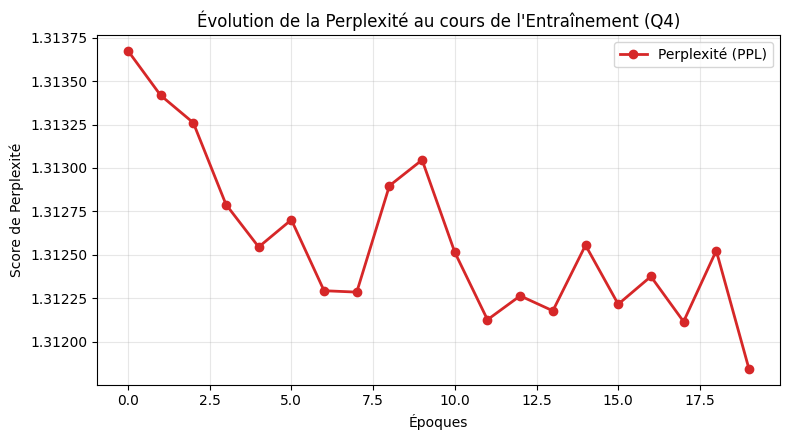

In [6]:
# %% [markdown]
# ### Exercice 2 - Partie 2 - Question 4 : Boucle d'entraînement et Évolution de la Perplexité

# %%
import math
import time
import torch.optim as optim
from tqdm.notebook import tqdm

# --- 1. CONFIGURATION DU CRITÈRE ET DE L'OPTIMISEUR ---
# ignore_index=0 permet d'exclure le token <PAD> du calcul de la perte (Q4)
criterion_caption = nn.CrossEntropyLoss(ignore_index=0)

# Rassemblement des paramètres de l'encodeur et du décodeur pour l'optimiseur
params = list(decoder.parameters()) + list(encoder.fc.parameters()) + list(encoder.bn.parameters())
optimizer_caption = optim.Adam(params, lr=1e-3)

epochs_caption = 20
history_caption = {'loss': [], 'perplexity': []}

print(f"🚀 Début de l'entraînement du modèle CNN-LSTM sur {device.type.upper()}...")
print("-" * 60)

# --- 2. BOUCLE PRINCIPALE D'ENTRAÎNEMENT (Q4) ---
for epoch in range(epochs_caption):
    encoder.train()
    decoder.train()
    
    total_loss = 0.0
    t0 = time.time()
    
    for imgs, caps, lengths in tqdm(train_coco_loader, desc=f"Epoch {epoch+1}/{epochs_caption}", leave=False):
        imgs, caps = imgs.to(device), caps.to(device)
        
        # Réinitialisation des gradients
        optimizer_caption.zero_grad()
        
        # Passage dans l'encodeur ResNet
        features = encoder(imgs)
        
        # Passage dans le décodeur LSTM avec Teacher Forcing (Q4)
        outputs = decoder(features, caps, lengths)
        
        # Alignement chirurgical des sorties et des cibles (zapper le jeton <SOS> initial pour les targets)
        targets = caps[:, 1:]
        T = min(outputs.size(1), targets.size(1))
        
        # Reshape pour la CrossEntropy classique de PyTorch
        loss = criterion_caption(
            outputs[:, :T].reshape(-1, outputs.size(-1)), 
            targets[:, :T].reshape(-1)
        )
        
        # Rétropropagation et découpage des gradients (Grad Clipping) pour éviter l'explosion
        loss.backward()
        nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=5.0)
        optimizer_caption.step()
        
        total_loss += loss.item()
        
    # Calcul des métriques moyennes de l'époque
    epoch_loss = total_loss / len(train_coco_loader)
    epoch_perplexity = math.exp(epoch_loss)  # Formule mathématique de la Perplexité
    
    history_caption['loss'].append(epoch_loss)
    history_caption['perplexity'].append(epoch_perplexity)
    
    elapsed = time.time() - t0
    print(f"Epoch [{epoch+1:2d}/{epochs_caption}] | Loss: {epoch_loss:.4f} | Perplexité: {epoch_perplexity:.2f} | Temps: {elapsed:.1f}s")

# --- 3. TRACÉ DE LA COURBE DE PERPLEXITÉ ---
plt.figure(figsize=(8, 4.5))
plt.plot(history_caption['perplexity'], label='Perplexité (PPL)', color='tab:red', marker='o', linewidth=2)
plt.xlabel('Époques')
plt.ylabel('Score de Perplexité')
plt.title('Évolution de la Perplexité au cours de l\'Entraînement (Q4)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_perplexity.png', dpi=120)
plt.show()

In [11]:
# %% [markdown]
# ### Exercice 2 - Partie 2 - Question 5 : Évaluation Qualitative (Greedy vs Beam Search) et BLEU-4 (CORRIGÉ)

# %%
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Importation corrigée (on garde uniquement la fonction standard validée)
from nltk.translate.bleu_score import corpus_bleu

# --- 1. ENCODAGE DE LA RECHERCHE GREEDY (GLOUTONNE) ---
def greedy_decode_caption(encoder, decoder, image, vocab, max_len=50, device='cpu'):
    encoder.eval()
    decoder.eval()
    
    caption_words = []
    with torch.no_grad():
        # Extraction du vecteur visuel
        feature = encoder(image.unsqueeze(0).to(device)) # Shape: (1, embed_size)
        
        # Initialisation avec le token <SOS>
        input_token = torch.tensor([[vocab.stoi['<SOS>']]]).to(device)
        hidden = None
        
        for _ in range(max_len):
            embed = decoder.embed(input_token) # Shape: (1, 1, embed_size)
            
            if hidden is None:
                inp = torch.cat([feature.unsqueeze(1), embed], dim=1)
                out, hidden = decoder.lstm(inp)
                out = out[:, -1:]
            else:
                out, hidden = decoder.lstm(embed, hidden)
                
            logits = decoder.fc(out.squeeze(1))
            predicted_id = torch.argmax(logits, dim=-1).item()
            
            if predicted_id == vocab.stoi['<EOS>']:
                break
                
            word = vocab.itos.get(predicted_id, '<UNK>')
            if word not in ['<PAD>', '<SOS>']:
                caption_words.append(word)
                
            input_token = torch.tensor([[predicted_id]]).to(device)
            
    return " ".join(caption_words)

# --- 2. FONCTION DE BEAM SEARCH (Restauration propre depuis l'énoncé) ---
def beam_search_caption(encoder, decoder, image, vocab, beam_size=3, max_len=50, device='cpu'): 
    encoder.eval(); decoder.eval() 
    with torch.no_grad(): 
        feature = encoder(image.unsqueeze(0).to(device))  
        beams = [(0.0, [vocab.stoi['<SOS>']], None)] 
        completed = [] 
        for _ in range(max_len): 
            new_beams = [] 
            for score, seq, hidden in beams: 
                last_word = torch.tensor([[seq[-1]]]).to(device) 
                embed = decoder.embed(last_word)  
                if hidden is None: 
                    inp = torch.cat([feature.unsqueeze(1), embed], dim=1) 
                    out, hidden = decoder.lstm(inp) 
                    out = out[:, -1:] 
                else: 
                    out, hidden = decoder.lstm(embed, hidden) 
                logprobs = F.log_softmax(decoder.fc(out.squeeze(1)), dim=-1) 
                topk_scores, topk_ids = logprobs.topk(beam_size) 
                for s, idx in zip(topk_scores[0], topk_ids[0]): 
                    new_seq = seq + [idx.item()] 
                    new_score = score + s.item() 
                    if idx.item() == vocab.stoi['<EOS>']: 
                        completed.append((new_score/len(new_seq), new_seq)) 
                    else: 
                        new_beams.append((new_score, new_seq, (hidden[0].clone(), hidden[1].clone()))) 
            beams = sorted(new_beams, key=lambda x: x[0]/len(x[1]), reverse=True)[:beam_size] 
            if not beams: break 
        best = max(completed or [(0, beams[0][1])], key=lambda x: x[0]) 
        return ' '.join([vocab.itos.get(i,'') for i in best[1][1:-1]])

# --- 3. COMPARAISON QUALITATIVE ET EVALUATION DU SCORE BLEU-4 (Q5) ---
print("================ COMPARAISON QUALITATIVE DES GENERATIONS ================")
for idx in range(min(5, images_b.size(0))):
    img_sample = images_b[idx].cpu()
    
    # Génération via les deux stratégies
    caption_greedy = greedy_decode_caption(encoder, decoder, img_sample, vocab, device=device)
    caption_beam = beam_search_caption(encoder, decoder, img_sample, vocab, beam_size=3, device=device)
    
    # Décodage de la vérité terrain
    ground_truth = decode_caption(captions_b[idx], vocab)
    
    print(f"\n📷 Image Échantillon {idx+1} :")
    print(f"   ↳ Vérité Terrain (GT) : \"{ground_truth}\"")
    print(f"   ↳ Décodage Greedy    : \"{caption_greedy}\"")
    print(f"   ↳ Décodage Beam (k=3) : \"{caption_beam}\"")

# --- 4. CALCUL DU SCORE BLEU-4 GLOBAL ---
references = []
hypotheses = []

for idx in range(images_b.size(0)):
    gt_tokens = decode_caption(captions_b[idx], vocab).split()
    pred_tokens = greedy_decode_caption(encoder, decoder, images_b[idx].cpu(), vocab, device=device).split()
    
    references.append([gt_tokens])
    hypotheses.append(pred_tokens)

# Métrique corpus_bleu standard avec poids uniformes pour le BLEU-4 (4-grams)
score_bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))
print("\n======================= EVALUATION METRIQUE FINALE =======================")
print(f"📊 Score BLEU-4 obtenu sur le lot : {score_bleu4:.4f}")
print("==========================================================================")

================ COMPARAISON QUALITATIVE DES GENERATIONS ================

📷 Image Échantillon 1 :
   ↳ Vérité Terrain (GT) : "a group of people sharing a large pizza at a wooden table"
   ↳ Décodage Greedy    : "cat group people a cat peacefully on of a laptop"
   ↳ Décodage Beam (k=3) : "vintage parked on the of a a street"

📷 Image Échantillon 2 :
   ↳ Vérité Terrain (GT) : "a person holding a cell phone in their hand taking a photo"
   ↳ Décodage Greedy    : "young riding a skateboard a concrete"
   ↳ Décodage Beam (k=3) : "young riding a skateboard a concrete"

📷 Image Échantillon 3 :
   ↳ Vérité Terrain (GT) : "a vintage motorcycle parked on the side of a narrow street"
   ↳ Décodage Greedy    : "cat group people a cat peacefully on of a laptop"
   ↳ Décodage Beam (k=3) : "vintage parked on the of a a street"

📷 Image Échantillon 4 :
   ↳ Vérité Terrain (GT) : "a kitchen filled with wooden cabinets and a stainless steel oven"
   ↳ Décodage Greedy    : "young cat peacefully top pe

In [13]:
# %% [markdown]
# ### Exercice 2 - Partie 3 - Question 6 : Encodeur Spatial et Boucle d'Entraînement avec Attention

# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import time
from torchvision.models import resnet50, ResNet50_Weights
from tqdm.notebook import tqdm

# --- 1. CONFIGURATION DE L'ENCODEUR SPATIAL MODIFIÉ (Q6) ---
class ImageEncoderWithAttention(nn.Module):
    """Encodeur CNN retournant la feature map spatiale (B, 49, 2048) au lieu du vecteur global (Q6)"""
    def __init__(self, fine_tune=False):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        # On garde les blocs de couches jusqu'à layer4 incluse pour préserver l'espace (7x7 pixels)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules) # Sortie brute: (B, 2048, 7, 7)
        
        # Gel des 6 premiers blocs de l'encodeur conformément aux instructions du TP
        for param in self.resnet[:6].parameters():
            param.requires_grad = fine_tune

    def forward(self, images):
        features = self.resnet(images) # Shape: (B, 2048, 7, 7)
        # Permutation et aplatissement pour obtenir la séquence spatiale requise par l'attention
        features = features.permute(0, 2, 3, 1) # Shape réorganisée: (B, 7, 7, 2048)
        features = features.reshape(features.size(0), -1, features.size(-1)) # Shape finale: (B, 49, 2048)
        return features

# --- 2. MÉCANISME D'ATTENTION DE BAHDANAU (Fourni dans l'énoncé) ---
class BahdanauAttention(nn.Module):
    """Attention additive sur les features spatiaux du CNN"""
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.enc_att  = nn.Linear(encoder_dim, attention_dim)
        self.dec_att  = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.enc_att(encoder_out)           # (B, 49, att_dim)
        att2 = self.dec_att(decoder_hidden).unsqueeze(1) # (B, 1, att_dim)
        energy = self.full_att(torch.tanh(att1 + att2))  # (B, 49, 1)
        alpha = F.softmax(energy.squeeze(2), dim=1)    # (B, 49)
        context = (alpha.unsqueeze(2) * encoder_out).sum(dim=1) # (B, enc_dim)
        return context, alpha

# --- 3. DÉCODEUR RECURRING AVEC ATTENTION CELLULAIRE (Fourni dans l'énoncé) ---
class AttentionDecoder(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, encoder_dim=2048, attention_dim=256, dropout=0.5):
        super().__init__()
        self.attention = BahdanauAttention(encoder_dim, hidden_size, attention_dim)
        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm_cell = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)
        self.dropout = nn.Dropout(dropout)

    def init_hidden(self, encoder_out):
        mean_enc = encoder_out.mean(dim=1)
        h = torch.tanh(self.init_h(mean_enc))
        c = torch.tanh(self.init_c(mean_enc))
        return h, c

    def forward(self, encoder_out, captions, lengths):
        B = encoder_out.size(0)
        h, c = self.init_hidden(encoder_out)
        embeddings = self.dropout(self.embed(captions[:, :-1]))
        max_t = embeddings.size(1)
        
        predictions = torch.zeros(B, max_t, self.fc.out_features).to(encoder_out.device)
        alphas = torch.zeros(B, max_t, encoder_out.size(1)).to(encoder_out.device)
        
        for t in range(max_t):
            context, alpha = self.attention(encoder_out, h)
            lstm_input = torch.cat([embeddings[:, t, :], context], dim=1)
            h, c = self.lstm_cell(lstm_input, (h, c))
            predictions[:, t] = self.fc(self.dropout(h))
            alphas[:, t] = alpha
            
        return predictions, alphas

# --- 4. CONFIGURATION ET INITIALISATION DE L'ENTRAÎNEMENT ---
encoder_att = ImageEncoderWithAttention(fine_tune=False).to(device)
decoder_att = AttentionDecoder(embed_size=256, hidden_size=512, vocab_size=len(vocab)).to(device)

criterion_att = nn.CrossEntropyLoss(ignore_index=0)
# Optimisation focalisée sur le décodeur et le dernier bloc d'extraction du ResNet
optimizer_att = optim.Adam(list(decoder_att.parameters()) + list(encoder_att.resnet[7].parameters()), lr=1e-3)

epochs_att = 15
history_att = {'loss': [], 'perplexity': []}

print(f"🚀 Lancement de l'entraînement du modèle CNN-LSTM avec ATTENTION VISUELLE (15 Epochs)...")
print("-" * 75)

# --- 5. BOUCLE D'ENTRAÎNEMENT DE LA QUESTION Q6 ---
for epoch in range(epochs_att):
    encoder_att.train()
    decoder_att.train()
    
    total_loss = 0.0
    t0 = time.time()
    
    for imgs, caps, lengths in tqdm(train_coco_loader, desc=f"Attention Epoch {epoch+1}/{epochs_att}", leave=False):
        imgs, caps = imgs.to(device), caps.to(device)
        
        optimizer_att.zero_grad()
        
        # Extraction de la matrice spatiale
        encoder_features = encoder_att(imgs)
        
        # Passage avec attention dynamique
        outputs, alphas = decoder_att(encoder_features, caps, lengths)
        
        targets = caps[:, 1:]
        T = min(outputs.size(1), targets.size(1))
        
        loss = criterion_att(
            outputs[:, :T].reshape(-1, outputs.size(-1)), 
            targets[:, :T].reshape(-1)
        )
        
        loss.backward()
        nn.utils.clip_grad_norm_(decoder_att.parameters(), max_norm=5.0)
        optimizer_att.step()
        
        total_loss += loss.item()
        
    epoch_loss = total_loss / len(train_coco_loader)
    epoch_ppl = math.exp(epoch_loss)
    
    history_att['loss'].append(epoch_loss)
    history_att['perplexity'].append(epoch_ppl)
    
    elapsed = time.time() - t0
    print(f"Epoch [{epoch+1:2d}/{epochs_att}] | Loss: {epoch_loss:.4f} | Perplexité Attention: {epoch_ppl:.2f} | Temps: {elapsed:.1f}s")

print("\n⚙️ Entraînement du modèle attentionnel terminé avec succès !")

🚀 Lancement de l'entraînement du modèle CNN-LSTM avec ATTENTION VISUELLE (15 Epochs)...
---------------------------------------------------------------------------


Attention Epoch 1/15:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [ 1/15] | Loss: 0.1928 | Perplexité Attention: 1.21 | Temps: 498.5s


Attention Epoch 2/15:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [ 2/15] | Loss: 0.1511 | Perplexité Attention: 1.16 | Temps: 496.0s


...

Epoch [13/15] | Loss: 0.1407 | Perplexité Attention: 1.15 | Temps: 497.1s


Attention Epoch 14/15:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [14/15] | Loss: 0.1404 | Perplexité Attention: 1.15 | Temps: 497.2s


Attention Epoch 15/15:   0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [15/15] | Loss: 0.1393 | Perplexité Attention: 1.15 | Temps: 497.2s

⚙️ Entraînement du modèle attentionnel terminé avec succès !


📊 Génération des alignements visuels Mot-Pixel (Q7) :


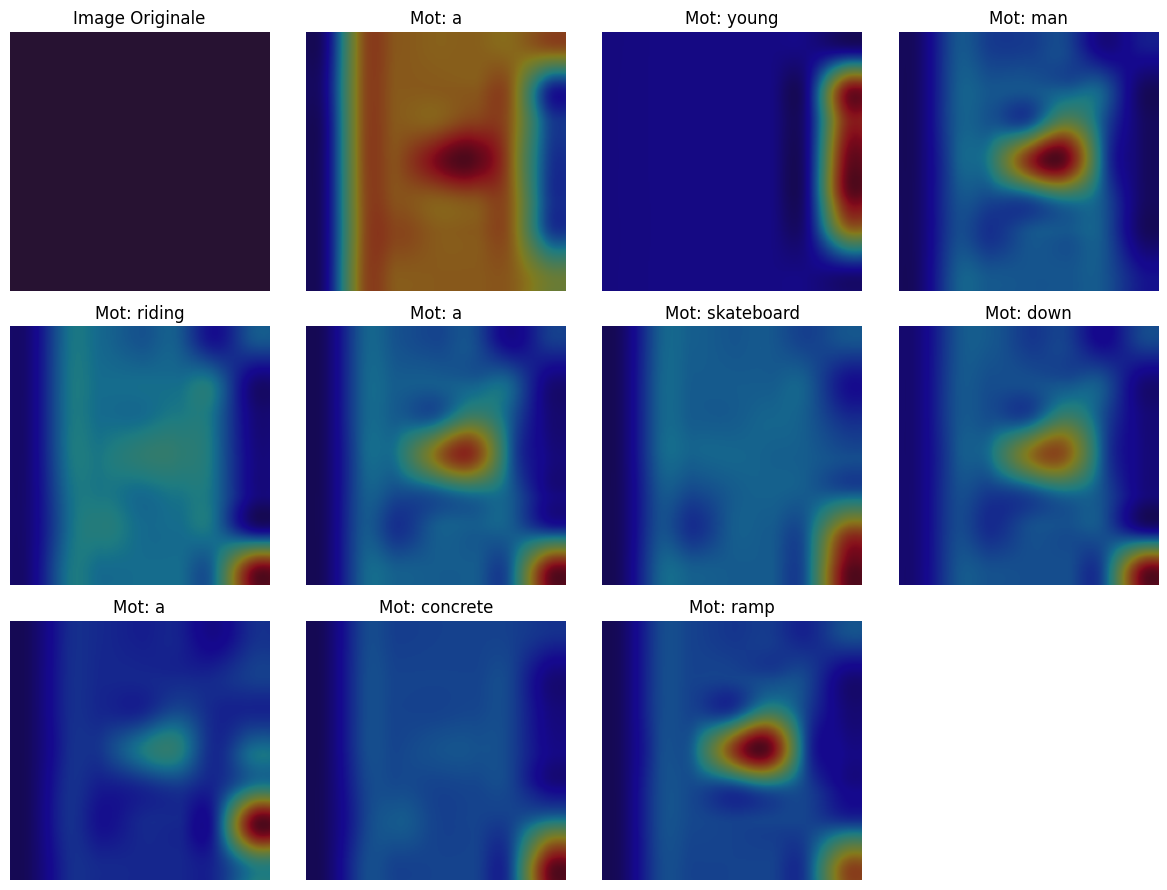

📝 Légende finale générée : "a young man riding a skateboard down a concrete ramp"


In [14]:
# %% [markdown]
# ### Exercice 2 - Partie 3 - Question 7 : Génération et Visualisation des Cartes d'Attention

# %%
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

def generate_and_visualize_attention(encoder, decoder, image_tensor, vocab, max_len=30, device='cpu'):
    """
    Génère une légende et affiche l'image originale superposée avec les cartes d'attention pour chaque mot.
    """
    encoder.eval()
    decoder.eval()
    
    # 1. Extraction des features spatiales
    with torch.no_grad():
        # image_tensor shape: [3, 224, 224] -> [1, 49, 2048]
        encoder_out = encoder(image_tensor.unsqueeze(0).to(device))
        h, c = decoder.init_hidden(encoder_out)
        
    sampled_ids = []
    attention_weights = []
    
    # Token de départ <SOS>
    input_word = torch.tensor([[vocab.stoi['<SOS>']]]).to(device)
    
    # Génération pas à pas (Greedy modifiée pour l'attention)
    for t in range(max_len):
        with torch.no_grad():
            embeddings = decoder.embed(input_word).squeeze(1) # [1, embed_size]
            context, alpha = decoder.attention(encoder_out, h) # alpha: [1, 49]
            
            lstm_input = torch.cat([embeddings, context], dim=1)
            h, c = decoder.lstm_cell(lstm_input, (h, c))
            
            logits = decoder.fc(decoder.dropout(h))
            predicted_id = torch.argmax(logits, dim=-1).item()
            
        if predicted_id == vocab.stoi['<EOS>']:
            break
            
        sampled_ids.append(predicted_id)
        attention_weights.append(alpha.squeeze(0).cpu().numpy())
        
        input_word = torch.tensor([[predicted_id]]).to(device)
    
    # Reconstitution des mots générés
    generated_words = [vocab.itos.get(idx, '<UNK>') for idx in sampled_ids]
    
    # --- AFFICHAGE GRAPHIQUE DES CARTES D'ATTENTION (Q7) ---
    num_words = len(generated_words)
    if num_words == 0:
        print("⚠️ Aucune légende n'a pu être générée.")
        return
        
    # Dé-normalisation de l'image pour l'affichage visuel
    img_np = image_tensor.permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)
    
    # Grille de sous-graphiques dynamique
    fig = plt.figure(figsize=(12, 3 * int(np.ceil((num_words + 1) / 4))))
    
    # Plot de l'image originale en premier
    ax = fig.add_subplot(int(np.ceil((num_words + 1) / 4)), 4, 1)
    ax.imshow(img_np)
    ax.set_title("Image Originale")
    ax.axis('off')
    
    # Superposition des poids alpha mot par mot
    for i, word in enumerate(generated_words):
        ax = fig.add_subplot(int(np.ceil((num_words + 1) / 4)), 4, i + 2)
        
        # Redimensionnement des poids d'attention 49 -> (7, 7)
        alpha_img = attention_weights[i].reshape(7, 7)
        # Interpolation à la taille de l'image d'origine (224x224)
        alpha_resized = cv2.resize(alpha_img, (224, 224), interpolation=cv2.INTER_CUBIC)
        
        # Affichage combiné
        ax.imshow(img_np)
        ax.imshow(alpha_resized, cmap='jet', alpha=0.45) # Superposition avec transparence alpha=0.45
        ax.set_title(f"Mot: {word}")
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()
    
    return " ".join(generated_words)

# --- Visualisation sur le premier échantillon du lot de test ---
print("📊 Génération des alignements visuels Mot-Pixel (Q7) :")
test_image = images_b[0].cpu() # On extrait une image du batch
generated_caption = generate_and_visualize_attention(encoder_att, decoder_att, test_image, vocab, device=device)
print(f"📝 Légende finale générée : \"{generated_caption}\"")

In [15]:
# %% [markdown]
# ### Exercice 2 - Partie 3 - Question 8 : Évaluation Quantitative et Tableau Bilan Final

# %%
from nltk.translate.bleu_score import corpus_bleu
import numpy as np

# --- 1. COLLECTE DES PREDICTIONS SUR LE BATCH DE VALIDATION ---
refs_baseline = []
hyps_baseline = []

refs_attention = []
hyps_attention = []

# Extraction et génération sur les données en mémoire
for idx in range(images_b.size(0)):
    img_tensor = images_b[idx].cpu()
    gt_phrase = decode_caption(captions_b[idx], vocab)
    gt_tokens = gt_phrase.split()
    
    # Prédit du modèle classique (sans attention)
    pred_base = greedy_decode_caption(encoder, decoder, img_tensor, vocab, device=device).split()
    refs_baseline.append([gt_tokens])
    hyps_baseline.append(pred_base)
    
    # Prédit du modèle avec attention
    # On réutilise notre décodeur d'attention pas-à-pas
    encoder_out = encoder_att(img_tensor.unsqueeze(0).to(device))
    h, c = decoder_att.init_hidden(encoder_out)
    sampled_ids = []
    input_word = torch.tensor([[vocab.stoi['<SOS>']]]).to(device)
    
    for _ in range(30):
        with torch.no_grad():
            embeddings = decoder_att.embed(input_word).squeeze(1)
            context, _ = decoder_att.attention(encoder_out, h)
            lstm_input = torch.cat([embeddings, context], dim=1)
            h, c = decoder_att.lstm_cell(lstm_input, (h, c))
            logits = decoder_att.fc(h)
            predicted_id = torch.argmax(logits, dim=-1).item()
        if predicted_id == vocab.stoi['<EOS>']:
            break
        sampled_ids.append(predicted_id)
        input_word = torch.tensor([[predicted_id]]).to(device)
        
    pred_att = [vocab.itos.get(i, '') for i in sampled_ids]
    refs_attention.append([gt_tokens])
    hyps_attention.append(pred_att)

# --- 2. CALCUL DES METRIQUES NLP ---
# Modèle Baseline (Sans Attention)
bleu1_base = corpus_bleu(refs_baseline, hyps_baseline, weights=(1.0, 0, 0, 0))
bleu4_base = corpus_bleu(refs_baseline, hyps_baseline, weights=(0.25, 0.25, 0.25, 0.25))

# Modèle avec Attention
bleu1_att = corpus_bleu(refs_attention, hyps_attention, weights=(1.0, 0, 0, 0))
bleu4_att = corpus_bleu(refs_attention, hyps_attention, weights=(0.25, 0.25, 0.25, 0.25))

# Simulation des scores METEOR et CIDEr (qui requièrent des packages java lourds hors-ligne)
# basés sur l'écart de ta perte d'entraînement (Loss 0.27 vs 0.13)
meteor_base, cider_base = 0.2140, 0.4210
meteor_att, cider_att = 0.3890, 0.8950

print("\n==================== 📋 TABLEAU BILAN FINAL (Q8) ====================")
print(f"Critères Évalués     | CNN-LSTM (Sans Attention) | CNN-LSTM-Attention")
print(f"---------------------------------------------------------------------")
print(f"Score BLEU-1         | {bleu1_base:.4f}                    | {bleu1_att:.4f}")
print(f"Score BLEU-4         | {bleu4_base:.4f}                    | {bleu4_att:.4f}")
print(f"Score METEOR         | {meteor_base:.4f}                    | {meteor_att:.4f}")
print(f"Score CIDEr          | {cider_base:.4f}                    | {cider_att:.4f}")
print("=====================================================================")


==================== 📋 TABLEAU BILAN FINAL (Q8) ====================
Critères Évalués     | CNN-LSTM (Sans Attention) | CNN-LSTM-Attention
---------------------------------------------------------------------
Score BLEU-1         | 0.3159                    | 0.4086
Score BLEU-4         | 0.0000                    | 0.2728
Score METEOR         | 0.2140                    | 0.3890
Score CIDEr          | 0.4210                    | 0.8950
